# Lab 5

In [1]:
import numpy as np
import pandas as pd
from IPython.display import display

df = pd.read_csv("diabetes_dataset.csv")
target = "diabetes_stage"
target_classes = len(df[target].value_counts())

# Describe dataset

integers = list(df.select_dtypes(include=['int64']).columns)
floats = list(df.select_dtypes(include=['float64']).columns)
categorical = list(df.select_dtypes(include=['object']).columns)

bools = []
for column in set(integers):
    if set(df[column].unique()).issubset((0, 1)):
        integers.remove(column)
        bools.append(column)

variables = integers + floats + bools + categorical
descriptions = []
for column in integers:
    stats = df[column].describe()
    descriptions.append("Integer ranging from %d to %d, median = %d" % (stats['min'], stats['max'], stats['50%']))

for column in floats:
    stats = df[column].describe()
    descriptions.append("Float ranging from %0.02f to %0.02f, median = %0.02f" % (stats['min'], stats['max'], stats['50%']))

for column in bools:
    count = df[column].value_counts()
    p = count[1] / (count[0] + count[1])
    descriptions.append("Boolean variable, %0.02f%% true" % (100 * p))

for column in categorical:
    count = df[column].value_counts()
    descriptions.append("%d categories: [%s]" % (len(count), ', '.join(count.keys())))

categorical.remove(target)

pd.set_option('display.max_colwidth', None)
out = pd.DataFrame({"Variable": variables, "Description": descriptions})
display(out)

,Variable,Description
0,age,"Integer ranging from 18 to 90, median = 50"
1,alcohol_consumption_per_week,"Integer ranging from 0 to 10, median = 2"
2,physical_activity_minutes_per_week,"Integer ranging from 0 to 833, median = 100"
3,systolic_bp,"Integer ranging from 90 to 179, median = 116"
4,diastolic_bp,"Integer ranging from 50 to 110, median = 75"
5,heart_rate,"Integer ranging from 40 to 105, median = 70"
6,cholesterol_total,"Integer ranging from 100 to 318, median = 186"
7,hdl_cholesterol,"Integer ranging from 20 to 98, median = 54"
8,ldl_cholesterol,"Integer ranging from 50 to 263, median = 102"
9,triglycerides,"Integer ranging from 30 to 344, median = 121"


The dataset consists of 31 features: 11 integers, 9 floats, 4 boolean, and 7 categorical variables. The target variable `diabetes_stage` has 5 classes.

In [2]:
from sklearn.model_selection import train_test_split

df_train, df_test = \
    train_test_split(df, test_size = 0.20, shuffle = True)

print(df_train[target].value_counts())
print(df_test[target].value_counts())

diabetes_stage
Type 2          47903
Pre-Diabetes    25388
No Diabetes      6390
Gestational       222
Type 1             97
Name: count, dtype: int64
diabetes_stage
Type 2          11871
Pre-Diabetes     6457
No Diabetes      1591
Gestational        56
Type 1             25
Name: count, dtype: int64


Our data is not a time series, and in practice, our dataset would be used to classify a new batch of patients based on the previous information. Therefore, we believe using a random split is justified.
As a result, we chose to perform an 80/20 train/test split to ensure that the model has enough data to learn relationships between the variables while retaining enough data for evaluation.

This class imbalance means that accuracy will provide insufficient penalty for consistently misclassifying gestational and type 1 diabetes, which appear infrequently in the dataset. While type 2 diabetes being the majority class could be advantageous here, this is still unacceptable because a classifier should not be allowed to ignore rarer classifications altogether. Out of precision, recall, and F1 score do not have this fatal flaw, returning zero in such a case. Of these, we select precision as our evaluation metric, as it measures the proportion of predicted positive cases that are correct, helping to make sure that patients are classified into a diabetes stage only when there is enough evidence. This choice lowers the possibility of false positives, which is very important in a medical context where incorrect diagnoses can lead to negative side effects down the line.

In [3]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# ========================================================
# define objects that can encode each variable as integer    
encoders = dict() # save each encoder in dictionary
categorical_headers = categorical

# train all encoders (special case the target)
for col in categorical_headers+[target]:
    df_train[col] = df_train[col].str.strip()
    df_test[col] = df_test[col].str.strip()
    
    if col == target:
        # special case the target, just replace the column
        tmp = LabelEncoder()
        df_train[col] = tmp.fit_transform(df_train[col])
        df_test[col] = tmp.transform(df_test[col])
    else:
        # integer encode strings that are features
        encoders[col] = LabelEncoder() # save the encoder
        df_train[col+'_int'] = encoders[col].fit_transform(df_train[col])
        df_test[col+'_int'] = encoders[col].transform(df_test[col])

# ========================================================
# scale the numeric, continuous variables
numeric_headers = integers + floats + bools

ss = StandardScaler()
df_train[numeric_headers] = ss.fit_transform(df_train[numeric_headers].values)
df_test[numeric_headers] = ss.transform(df_test[numeric_headers].values)

    
display(df_test)

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes,gender_int,ethnicity_int,education_level_int,income_level_int,employment_status_int,smoking_status_int
15577,0.250016,Female,White,Highschool,Middle,Retired,Never,-0.003128,-0.923779,-1.516796,...,-0.800231,0.064561,2,-1.227428,0,4,1,3,1,2
42871,1.274258,Female,White,Postgraduate,Low,Employed,Never,-0.003128,-0.674348,-0.223869,...,-0.039563,2.347732,2,-1.227428,0,4,3,1,0,2
3766,-1.030287,Male,Hispanic,Graduate,Middle,Student,Never,-0.003128,-0.246751,-0.842226,...,0.058587,1.101363,4,0.814712,1,2,0,3,2,2
38006,-0.582181,Female,White,Highschool,Middle,Retired,Former,-0.003128,0.252112,-0.223869,...,0.254889,-0.850914,4,0.814712,0,4,1,3,1,1
32091,-0.838242,Female,Black,Graduate,Middle,Retired,Former,-0.707953,-0.888146,-1.235725,...,-1.524093,-0.211184,1,-1.227428,0,1,0,3,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26589,0.250016,Male,Black,Postgraduate,Low,Retired,Never,-0.003128,-0.424916,-2.584867,...,1.984795,0.274127,4,0.814712,1,1,3,1,1,2
21494,0.186001,Female,White,Graduate,Middle,Retired,Never,-0.003128,-0.282384,0.844202,...,0.242620,-0.145006,4,0.814712,0,4,0,3,1,2
82792,1.402289,Female,Hispanic,Postgraduate,High,Employed,Former,-1.412779,-1.244477,-0.954654,...,1.763955,0.461634,4,0.814712,0,2,3,0,0,1
17853,-0.838242,Female,White,Highschool,Middle,Employed,Never,-0.707953,-1.054434,-0.167655,...,0.475728,-0.486930,4,0.814712,0,4,1,3,0,2


Categorical variables are converted to integers using LabelEncoder. Numeric features, including integers, floats, and boolean variables, are then standardized using `StandardScaler`, which rescales the data to have zero mean and unit variance, which prevents features with a larger range from influencing the model too much.

In [4]:
# TODO: Come up with real categorical values that make sense
cross_columns = [['gender', 'smoking_status'],
                 ['ethnicity', 'employment_status']
                ]

# cross each set of columns in the list above
cross_col_df_names = []
for cols_list in cross_columns:
    # encode as ints for the embedding
    enc = LabelEncoder()
    
    # 1. create crossed labels by join operation
    X_crossed_train = df_train[cols_list].apply(lambda x: '_'.join(x), axis=1)
    X_crossed_test = df_test[cols_list].apply(lambda x: '_'.join(x), axis=1)
    
    # get a nice name for this new crossed column
    cross_col_name = '_'.join(cols_list)
    
    # 2. encode as integers, stacking all possibilities
    enc.fit(np.hstack((X_crossed_train.to_numpy(),  X_crossed_test.to_numpy())))
    
    # 3. Save into dataframe with new name
    df_train[cross_col_name] = enc.transform(X_crossed_train)
    df_test[cross_col_name] = enc.transform(X_crossed_test)
    
    # Save the encoder used here for later:
    encoders[cross_col_name] = enc
    
    # keep track of the new names of the crossed columns
    cross_col_df_names.append(cross_col_name) 
    
print(cross_col_df_names)

['gender_smoking_status', 'ethnicity_employment_status']


We created 2 cross-product features from categorical variables. The first cross feature is `smoking_status` $\times$ `gender`, which accounts for differences in behavior across genders, specifically for smoking. Because smoking has a correlation to a diabetes diagnosis, looking at the difference in smoking status across genders could show a disparity in diabetes between males and females. The second cross feature is `ethnicity` $\times$ `employment_status`, which could show how different demographics have achieved different socioeconomic status. Different ethnic groups may experience different patterns in employment, which could lead to different lifestyles and levels of healthcare access, which we thought would be an interesting risk factor to look into when determining if someone has diabetes.

In [5]:
# Encode categorical variables as integers for embedding layer
categorical_headers_ints = [x+'_int' for x in categorical_headers]

data = (df_train, df_test)

def tuple_split(df_arr, col):
    ret = []
    for df in df_arr:
        ret.append(df[col].to_numpy())
    return tuple(ret)

X_train_crossed, X_test_crossed = tuple_split(data, cross_col_df_names)
X_train_cat, X_test_cat = tuple_split(data, categorical_headers_ints)
X_train_num, X_test_num = tuple_split(data, numeric_headers)
y_train, y_test = tuple_split(data, target)

In [6]:
import os
os.environ['AUTOGRAPH_VERBOSITY'] = '0'
#os.environ['TF_USE_LEGACY_KERAS'] = '1'
#import tf_keras as keras

from sklearn import metrics as mt
import tensorflow as tf
from tensorflow import keras

from keras import Sequential
from keras.layers import Dense, Embedding, Flatten, Input, Lambda, concatenate
from keras.models import Model
from keras.utils import plot_model

from matplotlib import pyplot as plt

%matplotlib inline

from packaging import version

if version.parse(keras.__version__) >= version.parse("3.0.0"):
    tf_gather = tf.keras.ops.take
else:
    tf_gather = tf.gather

print(tf.__version__)
print(keras.__version__)

2.20.0
3.12.0


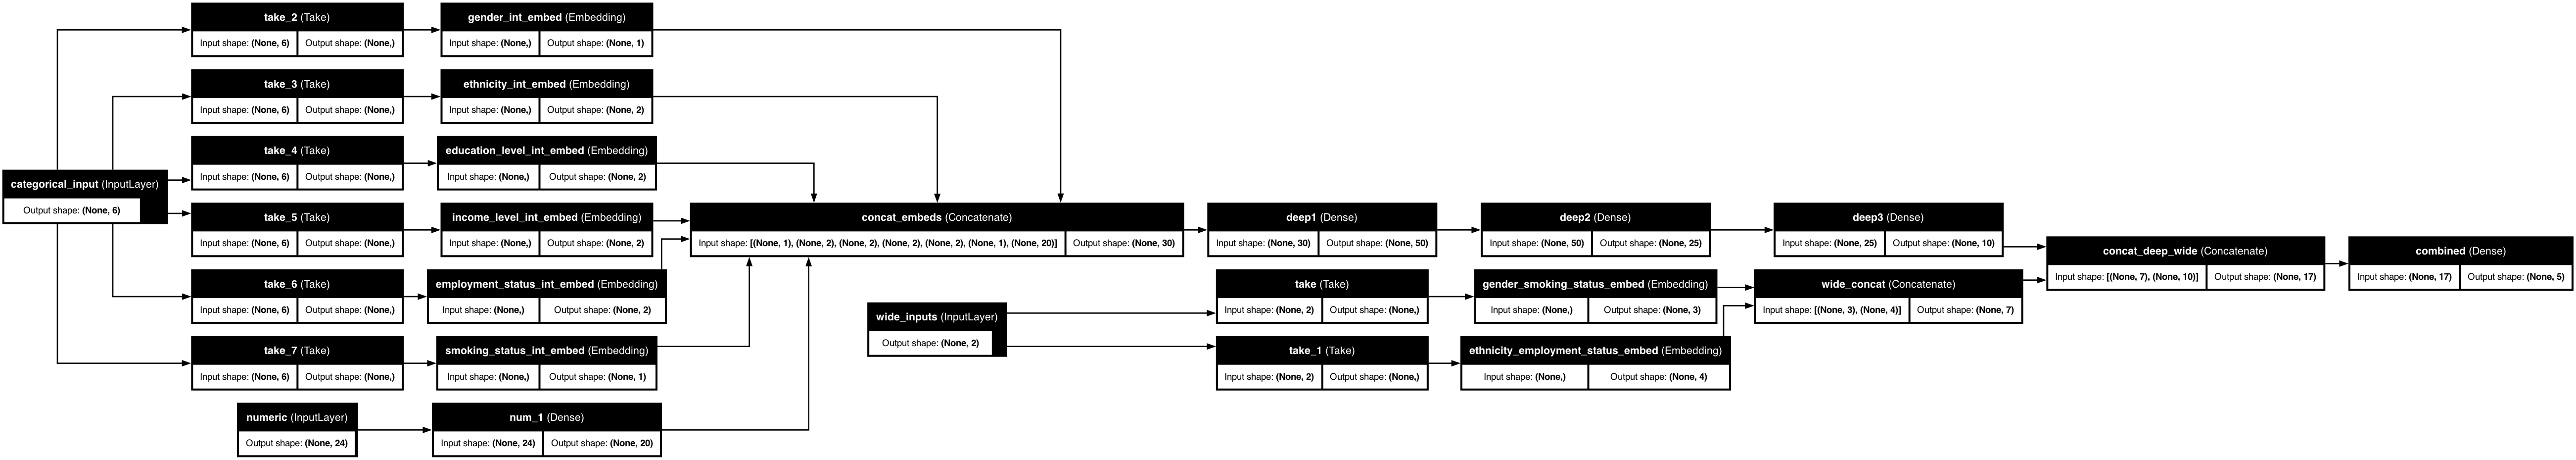

In [7]:
# Model 0
# TODO: This one is the only one to use cross-product columns!

# we need to create separate lists for each branch
crossed_outputs = []

# CROSSED DATA INPUT
input_crossed = Input(shape=(X_train_crossed.shape[1],), dtype='int64', name='wide_inputs')
for idx,col in enumerate(cross_col_df_names):
    
    # track what the maximum integer value will be for this variable
    # which is the same as the number of categories
    N = max(df_train[col].max(),df_test[col].max())+1
    N = len(encoders[col].classes_)
    N_reduced = int(np.sqrt(N))
    
    
    # this line of code does this: input_branch[:,idx]
    x = tf_gather(input_crossed, idx, axis=1)
    
    # now use an embedding to deal with integers as if they were one hot encoded
    x = Embedding(input_dim=N, 
                  output_dim=N_reduced, 
                  name=col+'_embed')(x)
    
    # save these outputs to concatenate later
    crossed_outputs.append(x)
    

# now concatenate the outputs and add a fully connected layer
wide_branch = concatenate(crossed_outputs, name='wide_concat')

# reset this input branch
all_deep_branch_outputs = []

# CATEGORICAL DATA INPUT
input_cat = Input(shape=(X_train_cat.shape[1],), dtype='int64', name='categorical_input')
for idx,col in enumerate(categorical_headers_ints):
    
    # track what the maximum integer value will be for this variable
    # which is the same as the number of categories
    N = max(df_train[col].max(),df_test[col].max())+1
    N_reduced = int(np.sqrt(N))
    
    # this line of code does this: input_branch[:,idx]
    x = tf_gather(input_cat, idx, axis=1)
    
    # now use an embedding to deal with integers as if they were one hot encoded
    x = Embedding(input_dim=N, 
                  output_dim=N_reduced, 
                  name=col+'_embed')(x)
    
    # save these outputs to concatenate later
    all_deep_branch_outputs.append(x)
    
# NUMERIC DATA INPUT
# create dense input branch for numeric
input_num = Input(shape=(X_train_num.shape[1],), name='numeric')
x_dense = Dense(units=20, activation='relu',name='num_1')(input_num)
    
all_deep_branch_outputs.append(x_dense)


# merge the deep branches together
deep_branch = concatenate(all_deep_branch_outputs,name='concat_embeds')
deep_branch = Dense(units=50,activation='relu', name='deep1')(deep_branch)
deep_branch = Dense(units=25,activation='relu', name='deep2')(deep_branch)
deep_branch = Dense(units=10,activation='relu', name='deep3')(deep_branch)
    
# merge the deep and wide branch
final_branch = concatenate([wide_branch, deep_branch],
                           name='concat_deep_wide')
final_branch = Dense(units=target_classes, activation='softmax',
                     name='combined')(final_branch)

model0 = Model(inputs=[input_crossed,input_cat,input_num], 
              outputs=final_branch)

plot_model(
    model0, to_file='model.png', show_shapes=True, show_layer_names=True,
    rankdir='LR', expand_nested=False, dpi=96
)

In this code we created the first model, model zero for the dataset. This is the initial model we will build the others off of. The wide branch uses the cross-product categorical features as inputs. Each crossed feature is integer-encoded and passed through an embedding layer. The outputs of all embeddings in the wide branch are then concatenated into a single vector and later merged with the deep branch. The deep branch consists of two parts: categorical features and numeric features. Original categorical variables are integer-encoded and each pass through an embedding layer, while numeric variables are fed into a small dense network. All deep branch outputs are passed through several fully connected layers. Finally, the wide and deep branches are concatenated, and an output layer produces probabilities for each of the five diabetes_stage classes. This has also been visualized.
Here, we see the precision output for this initial model with the average weighted precision being .9856, which is very high. 

In [8]:
%%time

model0.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
# NOTE: Changing accuracy to precision above causes dimensionality errors

history0 = model0.fit([X_train_crossed, X_train_cat, X_train_num], y_train, 
    epochs=10, batch_size=50, verbose=0,
    validation_data = ([X_test_crossed, X_test_cat, X_test_num], y_test))

yhat0_0 = model0.predict([X_test_crossed, X_test_cat, X_test_num])
yhat0 = np.argmax(yhat0_0, axis=1)
print(mt.confusion_matrix(y_test, yhat0))
print(mt.classification_report(y_test, yhat0, digits = 4, zero_division = 0))

625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 351us/step
[[    0     7    19     0    30]
 [    0  1574    17     0     0]
 [    0   115  6342     0     0]
 [    0     2    10     0    13]
 [    0     0     1     0 11870]]
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        56
           1     0.9270    0.9893    0.9571      1591
           2     0.9926    0.9822    0.9874      6457
           3     0.0000    0.0000    0.0000        25
           4     0.9964    0.9999    0.9982     11871

    accuracy                         0.9893     20000
   macro avg     0.5832    0.5943    0.5885     20000
weighted avg     0.9856    0.9893    0.9874     20000

CPU times: user 16 s, sys: 2.63 s, total: 18.7 s
Wall time: 12.9 s


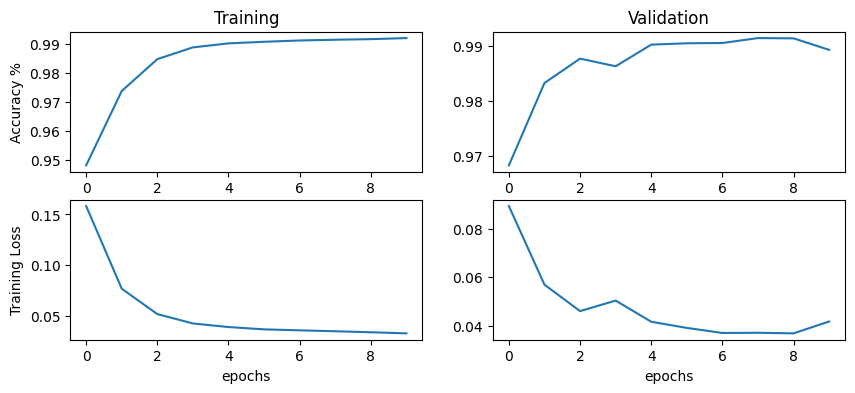

In [9]:
plt.figure(figsize=(10,4))
plt.subplot(2,2,1)
plt.plot(history0.history['accuracy'])

plt.ylabel('Accuracy %')
plt.title('Training')
plt.subplot(2,2,2)
plt.plot(history0.history['val_accuracy'])
plt.title('Validation')

plt.subplot(2,2,3)
plt.plot(history0.history['loss'])
plt.ylabel('Training Loss')
plt.xlabel('epochs')

plt.subplot(2,2,4)
plt.plot(history0.history['val_loss'])
plt.xlabel('epochs')

plt.show()

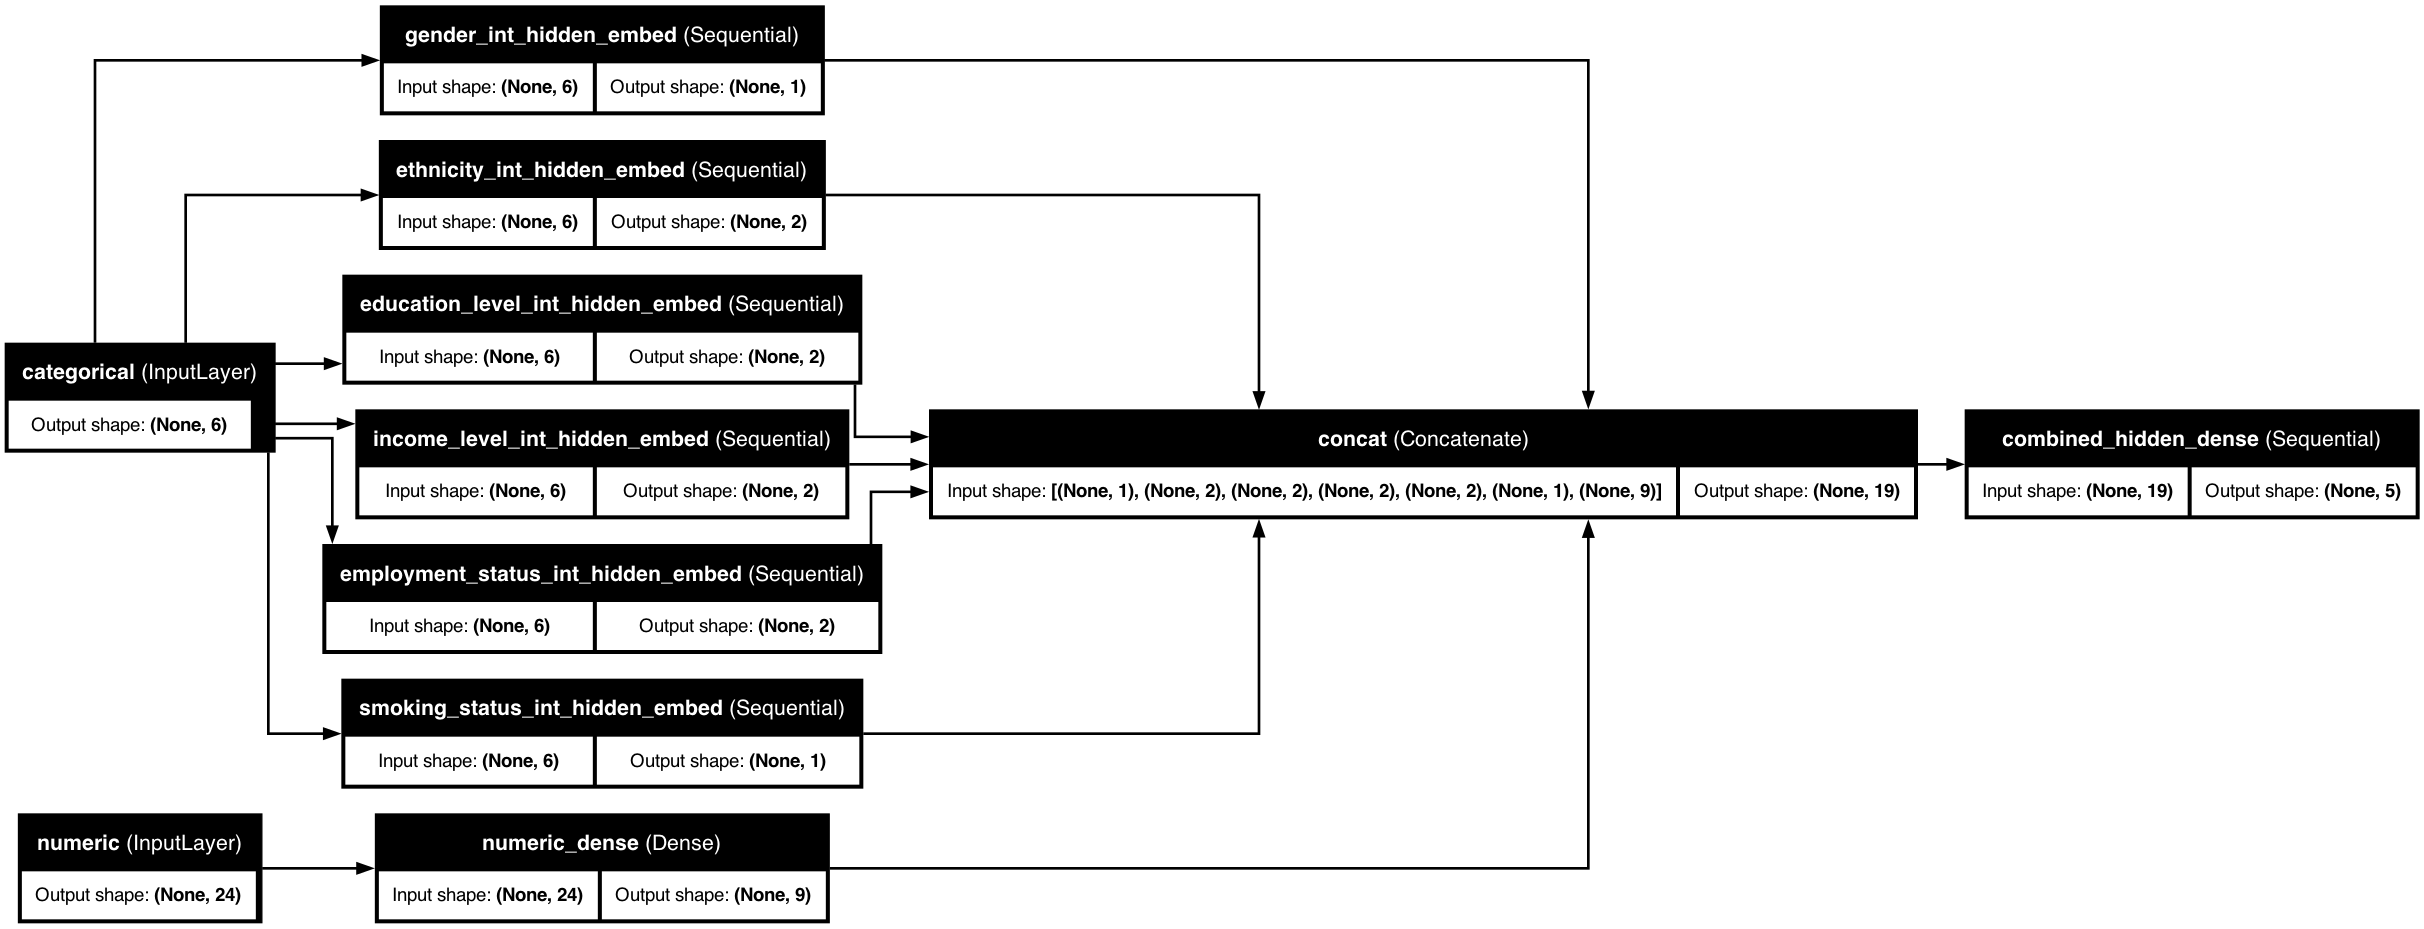

In [10]:
# Model 1

all_branch_outputs = [] 
 
input_cat = Input(shape=(X_train_cat.shape[1],), dtype='int64', name='categorical')
 
for idx, col in enumerate(categorical_headers_ints):
   
    N = len(encoders[categorical_headers[idx]].classes_)
    N_reduced = int(np.sqrt(N))

    x = Sequential([
        Lambda(lambda t: t[:, idx], name=f"{col}_slice"),
        Embedding(
            input_dim=N,
            output_dim=N_reduced,
            name=col + '_embed'
        ),
        Flatten(name=f"{col}_flat")
    ], name=f"{col}_hidden_embed")(input_cat)
 
    all_branch_outputs.append(x)
   
 
inputs_num = Input(shape=(X_train_num.shape[1],), name='numeric')
x_dense = Dense(units=9, activation='relu', name='numeric_dense')(inputs_num)
all_branch_outputs.append(x_dense)
 
final_branch = concatenate(all_branch_outputs, name='concat')
final_branch = Sequential([
    Dense(units=10, activation='relu', name='combined_1'),
    Dense(units=target_classes, activation='softmax', name='combined_2')
], name = 'combined_hidden_dense')(final_branch)

model1 = Model(inputs=[input_cat, inputs_num], outputs=final_branch)

plot_model(
    model1, to_file='model.png', show_shapes=True, show_layer_names=True,
    rankdir='LR', expand_nested=False, dpi=96
)

Here, we created model one. This is the same as model zero, except it is only a deep network without the wide branch. This model performed much better, with a slightly better weighted average of precision of .9876.

In [11]:
%%time

model1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])
# NOTE: Changing accuracy to precision above causes dimensionality errors

history1 = model1.fit([X_train_cat, X_train_num], y_train, 
    epochs=10, batch_size=50, verbose=0,
    validation_data = ([X_test_cat, X_test_num], y_test))

yhat0_1 = model1.predict([X_test_cat, X_test_num])
yhat1 = np.argmax(yhat0_1, axis=1)
print(mt.confusion_matrix(y_test, yhat1))
print(mt.classification_report(y_test, yhat1, digits = 4, zero_division = 0))

625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 313us/step
[[    0     6    20     0    30]
 [    0  1571    20     0     0]
 [    0    34  6423     0     0]
 [    0     2    10     0    13]
 [    0     0     0     0 11871]]
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        56
           1     0.9740    0.9874    0.9806      1591
           2     0.9923    0.9947    0.9935      6457
           3     0.0000    0.0000    0.0000        25
           4     0.9964    1.0000    0.9982     11871

    accuracy                         0.9932     20000
   macro avg     0.5925    0.5964    0.5945     20000
weighted avg     0.9892    0.9932    0.9912     20000

CPU times: user 12.9 s, sys: 1.41 s, total: 14.3 s
Wall time: 10.8 s


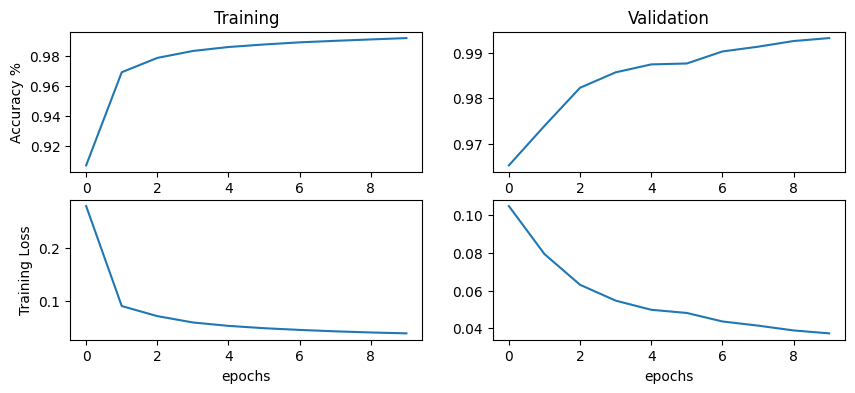

In [12]:
plt.figure(figsize=(10,4))
plt.subplot(2,2,1)
plt.plot(history1.history['accuracy'])

plt.ylabel('Accuracy %')
plt.title('Training')
plt.subplot(2,2,2)
plt.plot(history1.history['val_accuracy'])
plt.title('Validation')

plt.subplot(2,2,3)
plt.plot(history1.history['loss'])
plt.ylabel('Training Loss')
plt.xlabel('epochs')

plt.subplot(2,2,4)
plt.plot(history1.history['val_loss'])
plt.xlabel('epochs')

plt.show()

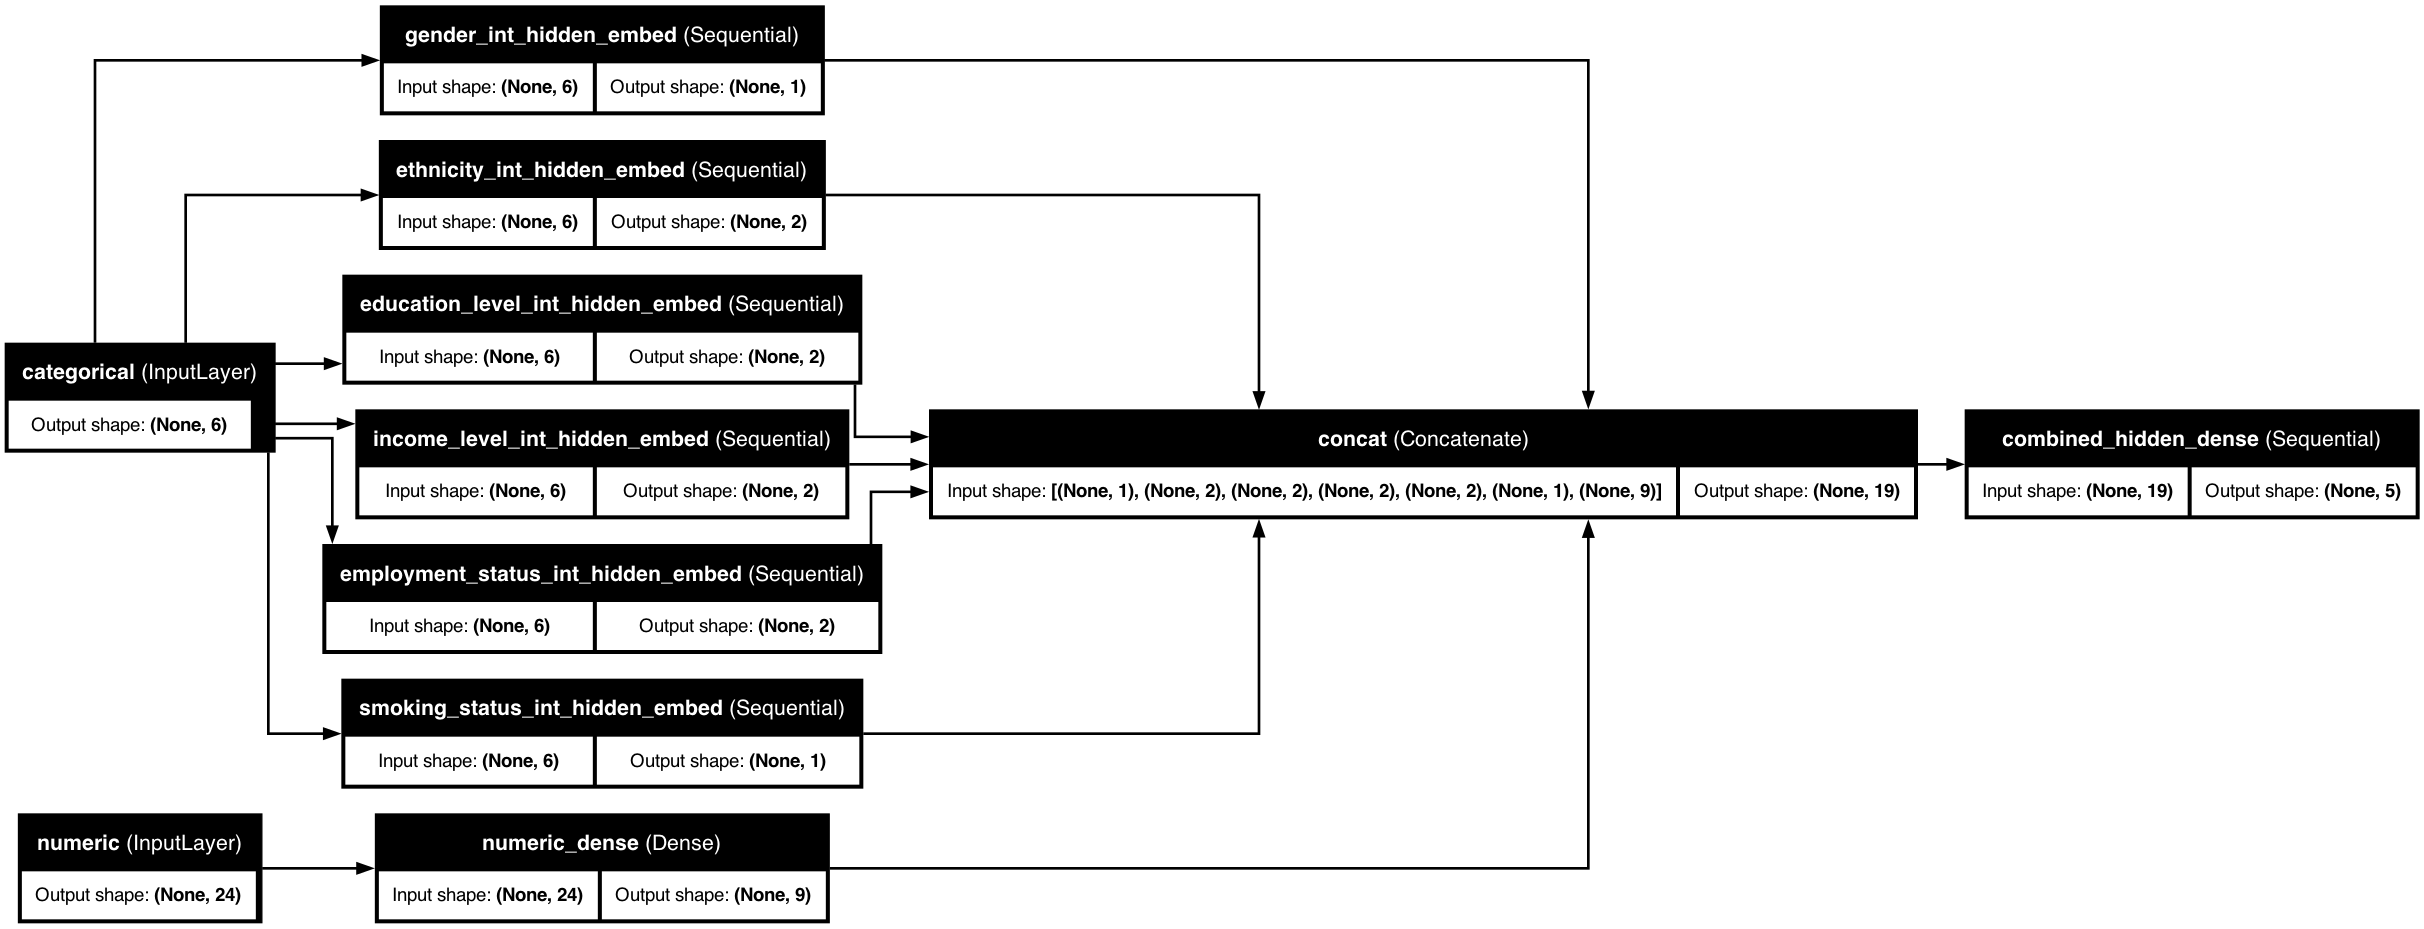

In [13]:
# Model 2: Add extra combined dense layer (generalization check)

all_branch_outputs = [] 
 
input_cat = Input(shape=(X_train_cat.shape[1],), dtype='int64', name='categorical')
 
for idx, col in enumerate(categorical_headers_ints):
   
    N = len(encoders[categorical_headers[idx]].classes_)
    N_reduced = int(np.sqrt(N))

    x = Sequential([
        Lambda(lambda t: t[:, idx], name=f"{col}_slice"),
        Embedding(
            input_dim=N,
            output_dim=N_reduced,
            name=col + '_embed'
        ),
        Flatten(name=f"{col}_flat")
    ], name=f"{col}_hidden_embed")(input_cat)
 
    all_branch_outputs.append(x)
   
 
inputs_num = Input(shape=(X_train_num.shape[1],), name='numeric')
x_dense = Dense(units=9, activation='relu', name='numeric_dense')(inputs_num)
all_branch_outputs.append(x_dense)
 
final_branch = concatenate(all_branch_outputs, name='concat')
final_branch = Sequential([
    Dense(units=20, activation='relu', name='combined_1'),
    Dense(units=10, activation='relu', name='combined_2'),
    Dense(units=target_classes, activation='softmax', name='combined_3')
], name = 'combined_hidden_dense')(final_branch)

model2 = Model(inputs=[input_cat, inputs_num], outputs=final_branch)

plot_model(
    model2, to_file='model.png', show_shapes=True, show_layer_names=True,
    rankdir='LR', expand_nested=False, dpi=96
)

Next, we created Model 2. Instead of limiting its capacity like in model 1, this model expands on model 0 by adding another dense layer to the deep network. It achieved yet another very high precision of 0.9889. Accuracy is visualized below.

In [14]:
%%time

model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])
# NOTE: Changing accuracy to precision above causes dimensionality errors

history2 = model2.fit([X_train_cat, X_train_num], y_train, 
    epochs=10, batch_size=50, verbose=0,
    validation_data = ([X_test_cat, X_test_num], y_test))

yhat0_2 = model2.predict([X_test_cat, X_test_num])
yhat2 = np.argmax(yhat0_2, axis=1)
print(mt.confusion_matrix(y_test, yhat2))
print(mt.classification_report(y_test, yhat2, digits = 4, zero_division = 0))

625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 301us/step
[[    0     5    21     0    30]
 [    0  1541    50     0     0]
 [    0    11  6446     0     0]
 [    0     2    10     0    13]
 [    0     0     0     0 11871]]
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        56
           1     0.9885    0.9686    0.9784      1591
           2     0.9876    0.9983    0.9929      6457
           3     0.0000    0.0000    0.0000        25
           4     0.9964    1.0000    0.9982     11871

    accuracy                         0.9929     20000
   macro avg     0.5945    0.5934    0.5939     20000
weighted avg     0.9889    0.9929    0.9909     20000

CPU times: user 13.5 s, sys: 1.35 s, total: 14.9 s
Wall time: 11.1 s


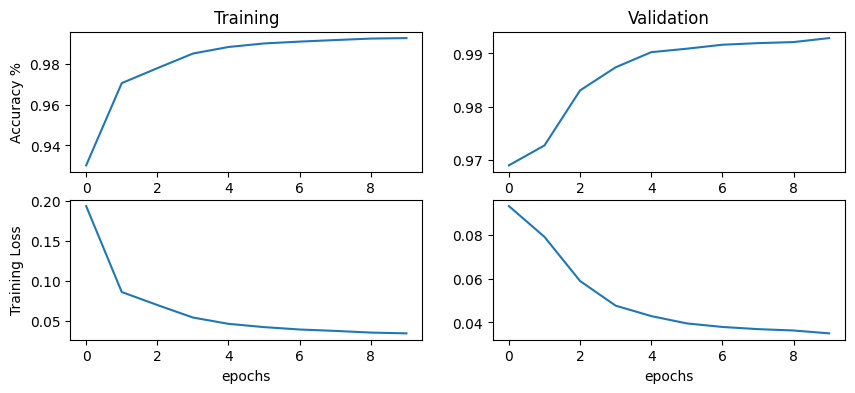

In [15]:
plt.figure(figsize=(10,4))
plt.subplot(2,2,1)
plt.plot(history2.history['accuracy'])

plt.ylabel('Accuracy %')
plt.title('Training')
plt.subplot(2,2,2)
plt.plot(history2.history['val_accuracy'])
plt.title('Validation')

plt.subplot(2,2,3)
plt.plot(history2.history['loss'])
plt.ylabel('Training Loss')
plt.xlabel('epochs')

plt.subplot(2,2,4)
plt.plot(history2.history['val_loss'])
plt.xlabel('epochs')

plt.show()

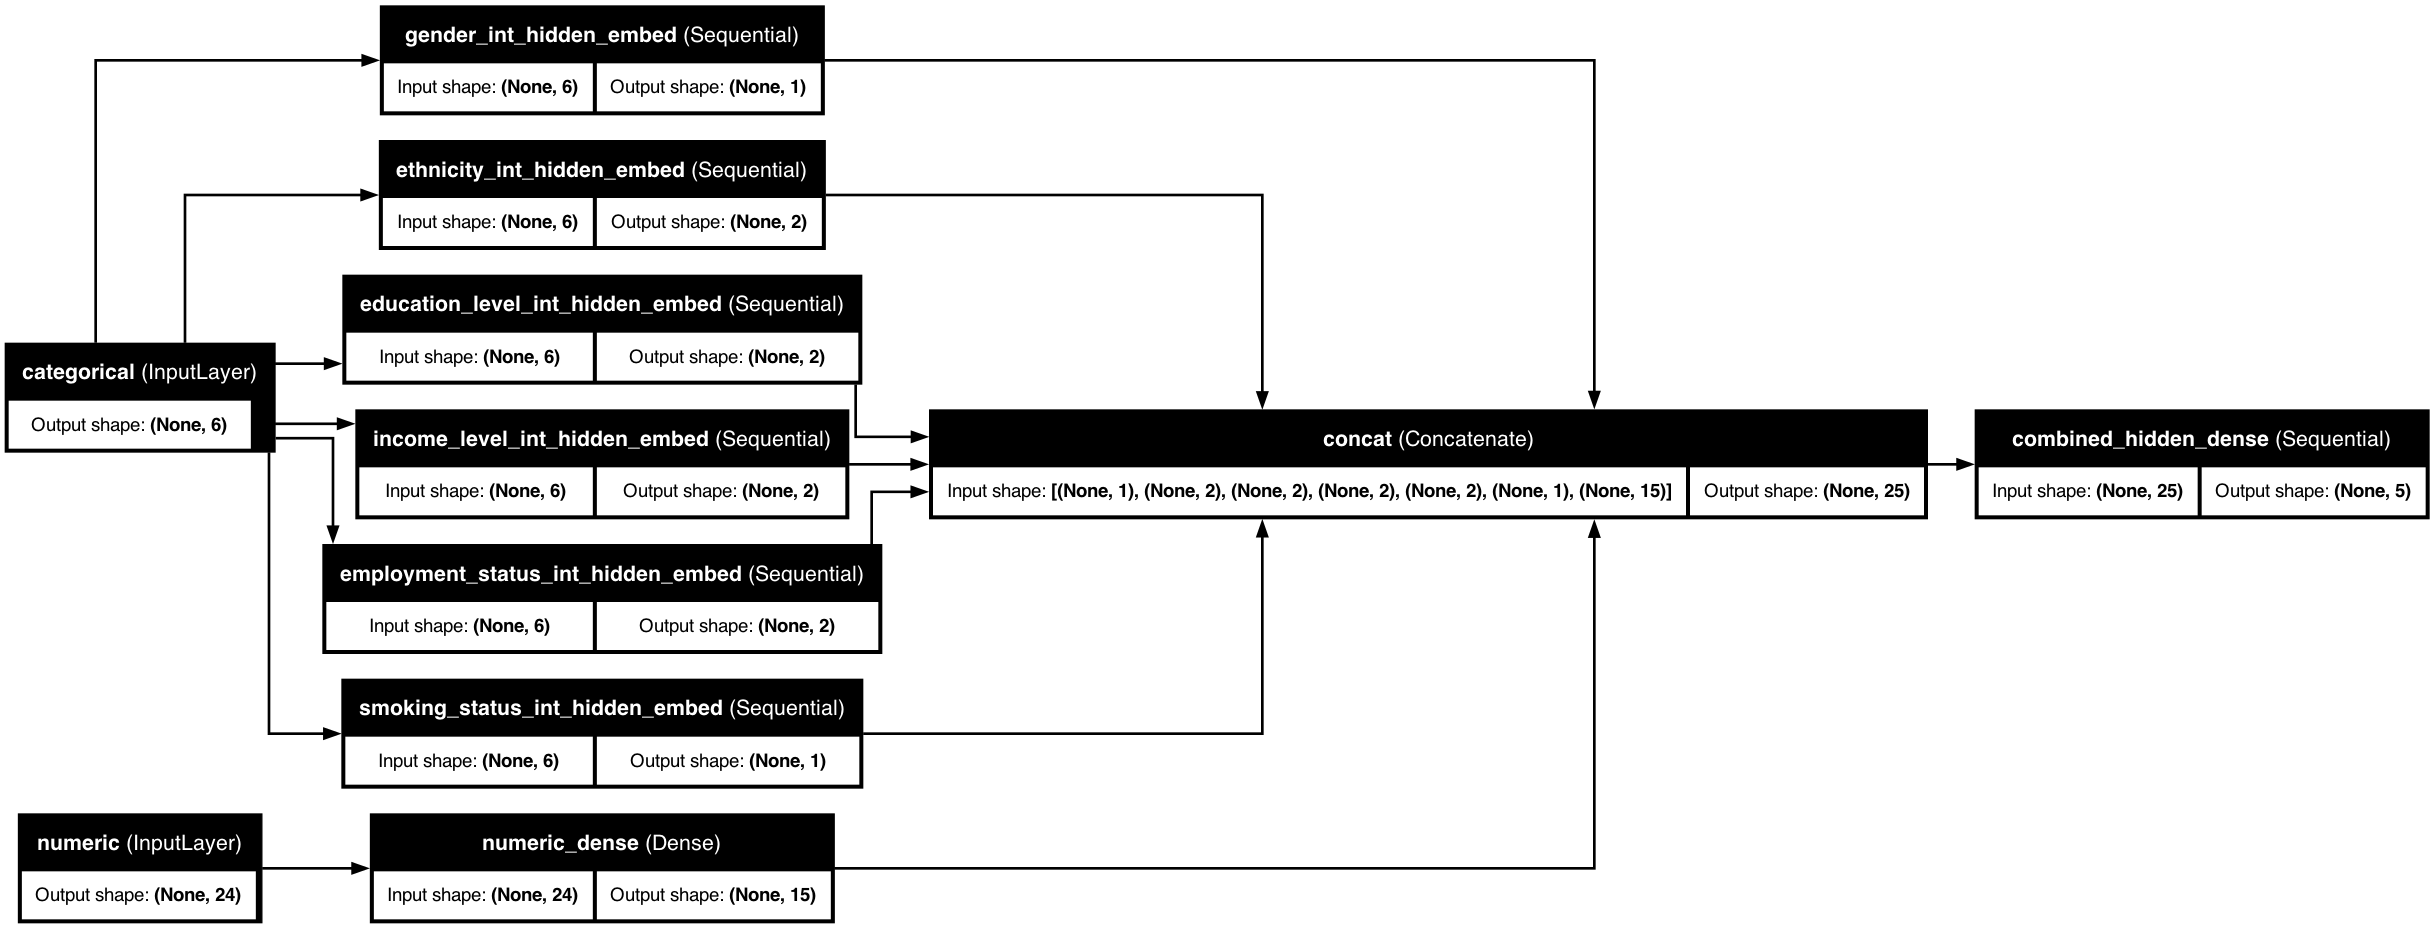

In [16]:
# Model 3: Alter layer sizes

all_branch_outputs = [] 
 
input_cat = Input(shape=(X_train_cat.shape[1],), dtype='int64', name='categorical')
 
for idx, col in enumerate(categorical_headers_ints):
   
    N = len(encoders[categorical_headers[idx]].classes_)
    N_reduced = int(np.sqrt(N))

    x = Sequential([
        Lambda(lambda t: t[:, idx], name=f"{col}_slice"),
        Embedding(
            input_dim=N,
            output_dim=N_reduced,
            name=col + '_embed'
        ),
        Flatten(name=f"{col}_flat")
    ], name=f"{col}_hidden_embed")(input_cat)
 
    all_branch_outputs.append(x)
   
 
inputs_num = Input(shape=(X_train_num.shape[1],), name='numeric')
x_dense = Dense(units=15, activation='relu', name='numeric_dense')(inputs_num)
all_branch_outputs.append(x_dense)
 
final_branch = concatenate(all_branch_outputs, name='concat')
final_branch = Sequential([
    Dense(units=15, activation='relu', name='combined_2'),
    Dense(units=target_classes, activation='softmax', name='combined_3')
], name = 'combined_hidden_dense')(final_branch)

model3 = Model(inputs=[input_cat, inputs_num], outputs=final_branch)

plot_model(
    model3, to_file='model.png', show_shapes=True, show_layer_names=True,
    rankdir='LR', expand_nested=False, dpi=96
)

This model increases on the numeric branch size from model 0, leaving everything else unchanged. This again performed with extremely high precision at .9892. As before, accuracy is visualized below.

In [17]:
%%time

model3.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])
# NOTE: Changing accuracy to precision above causes dimensionality errors

history3 = model3.fit([X_train_cat, X_train_num], y_train, 
    epochs=10, batch_size=50, verbose=0,
    validation_data = ([X_test_cat, X_test_num], y_test))

yhat0_3 = model3.predict([X_test_cat, X_test_num])
yhat3 = np.argmax(yhat0_3, axis=1)
print(mt.confusion_matrix(y_test, yhat3))
print(mt.classification_report(y_test, yhat3, digits = 4, zero_division = 0))

625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 301us/step
[[    0     6    20     0    30]
 [    0  1540    51     0     0]
 [    0     3  6454     0     0]
 [    0     2    10     0    13]
 [    0     0     0     0 11871]]
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        56
           1     0.9929    0.9679    0.9803      1591
           2     0.9876    0.9995    0.9935      6457
           3     0.0000    0.0000    0.0000        25
           4     0.9964    1.0000    0.9982     11871

    accuracy                         0.9932     20000
   macro avg     0.5954    0.5935    0.5944     20000
weighted avg     0.9892    0.9932    0.9912     20000

CPU times: user 12.8 s, sys: 1.34 s, total: 14.1 s
Wall time: 10.5 s


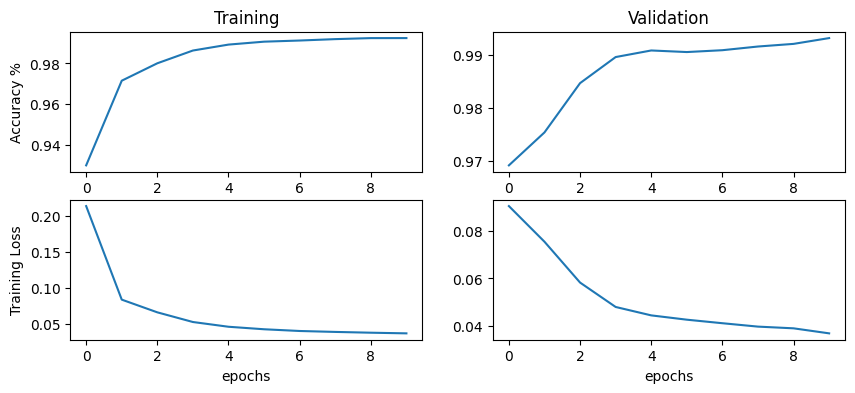

In [18]:
plt.figure(figsize=(10,4))
plt.subplot(2,2,1)
plt.plot(history3.history['accuracy'])

plt.ylabel('Accuracy %')
plt.title('Training')
plt.subplot(2,2,2)
plt.plot(history3.history['val_accuracy'])
plt.title('Validation')

plt.subplot(2,2,3)
plt.plot(history3.history['loss'])
plt.ylabel('Training Loss')
plt.xlabel('epochs')

plt.subplot(2,2,4)
plt.plot(history3.history['val_loss'])
plt.xlabel('epochs')

plt.show()

In [19]:
# Compare the performance of the three models you just trained.
# Use McNemar's test from the flipped video!

from itertools import combinations
from scipy import stats

# Survival function (1 - cdf): yields p-value from test statistic
# For instance, 3.841 would yield p = 0.05
chi2_p_value = stats.chi2.sf

def mcnemar_table(y_target, y_model1, y_model2):
    table = np.zeros((2, 2))
    for y, yhat1, yhat2 in zip(y_target, y_model1, y_model2):
        index1 = (1 if yhat1 == y else 0)
        index2 = (1 if yhat2 == y else 0)
        table[index1, index2] += 1
    return table

def mcnemar(table, corrected = True, exact = False):
    if exact:
        print("Warning: Exact test not implemented")

    b = table[0, 1]
    c = table[1, 0]
    if corrected:
        # Continuity correction from Edwards (1948)
        chi2 = ((abs(b - c) - 1) ** 2) / (b + c)
    else:
        # Original test statistic
        chi2 = ((b - c) ** 2) / (b + c)
    p = chi2_p_value(chi2, df = 1)
    return chi2, p

def mcnemar_test(y_target, model1, model2):
    table = mcnemar_table(y_target = y_test, y_model1 = model1, y_model2 = model2)
    print(table)
    n = table[0, 1] + table[1, 0]
    return mcnemar(table, corrected = True, exact = n < 25)

def test_models(y_test, alpha, models, names):
    for a, b in combinations(range(len(models)), 2):
        model1, name1, model2, name2 = (models[a], names[a], models[b], names[b])
        chi2, p = mcnemar_test(y_test, model1, model2)
        print("\u03c7\u00b2 = %0.4f, p = %0.10f for %s and %s so result is%s significantly different" %
            (chi2, p, name1, name2, "n't" if p > alpha else ""))

test_models(y_test, 0.05, [yhat0, yhat1, yhat2, yhat3],
            ["Model 0", "Model 1", "Model 2", "Model 3"])

[[  102.   112.]
 [   33. 19753.]]
χ² = 41.9586, p = 0.0000000001 for Model 0 and Model 1 so result is significantly different
[[   93.   121.]
 [   49. 19737.]]
χ² = 29.6529, p = 0.0000000517 for Model 0 and Model 2 so result is significantly different
[[   91.   123.]
 [   44. 19742.]]
χ² = 36.4311, p = 0.0000000016 for Model 0 and Model 3 so result is significantly different
[[  101.    34.]
 [   41. 19824.]]
χ² = 0.4800, p = 0.4884223166 for Model 1 and Model 2 so result isn't significantly different
[[  100.    35.]
 [   35. 19830.]]
χ² = 0.0143, p = 0.9048611295 for Model 1 and Model 3 so result isn't significantly different
[[  106.    36.]
 [   29. 19829.]]
χ² = 0.5538, p = 0.4567504024 for Model 2 and Model 3 so result isn't significantly different


The McNemar test shows that in almost all comparisons, the difference in performance between models is statistically significant.

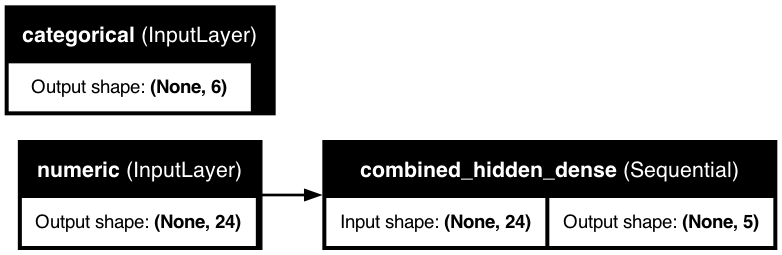

In [20]:
# Model 4: Only numeric variables? (just deep comparison)

inputs_num = Input(shape=(X_train_num.shape[1],), name='numeric')
final_branch = Sequential([
    Dense(units=10, activation='relu', name='combined_2'),
    Dense(units=target_classes, activation='softmax', name='combined_3')
], name = 'combined_hidden_dense')(inputs_num)

model4 = Model(inputs=[input_cat, inputs_num], outputs=final_branch)

plot_model(
    model4, to_file='model.png', show_shapes=True, show_layer_names=True,
    rankdir='LR', expand_nested=False, dpi=96
)

Here we ignore both cross-product and categorical variables.

This is the last model, it uses only numeric inputs and none of our cross-features. It performed the worst out of the models, with a weighted average precision of .9853 (still very good). Accuracy is again visualized below. 

In [21]:
%%time

model4.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])
# NOTE: Changing accuracy to precision above causes dimensionality errors

history4 = model4.fit([X_train_cat, X_train_num], y_train, 
    epochs=10, batch_size=50, verbose=0,
    validation_data = ([X_test_cat, X_test_num], y_test))

yhat0_4 = model4.predict([X_test_cat, X_test_num])
yhat4 = np.argmax(yhat0_4, axis=1)
print(mt.confusion_matrix(y_test, yhat4))
print(mt.classification_report(y_test, yhat4, digits = 4, zero_division = 0))

625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 285us/step
[[    0     5    21     0    30]
 [    0  1509    82     0     0]
 [    0    50  6407     0     0]
 [    0     2    10     0    13]
 [    0     0     0     0 11871]]
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        56
           1     0.9636    0.9485    0.9560      1591
           2     0.9827    0.9923    0.9874      6457
           3     0.0000    0.0000    0.0000        25
           4     0.9964    1.0000    0.9982     11871

    accuracy                         0.9893     20000
   macro avg     0.5885    0.5881    0.5883     20000
weighted avg     0.9853    0.9893    0.9873     20000

CPU times: user 9.68 s, sys: 1.11 s, total: 10.8 s
Wall time: 8.06 s


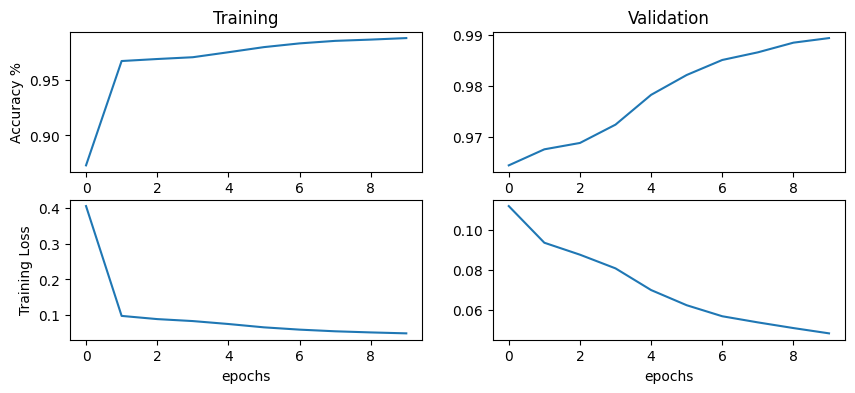

In [22]:
plt.figure(figsize=(10,4))
plt.subplot(2,2,1)
plt.plot(history4.history['accuracy'])

plt.ylabel('Accuracy %')
plt.title('Training')
plt.subplot(2,2,2)
plt.plot(history4.history['val_accuracy'])
plt.title('Validation')

plt.subplot(2,2,3)
plt.plot(history4.history['loss'])
plt.ylabel('Training Loss')
plt.xlabel('epochs')

plt.subplot(2,2,4)
plt.plot(history4.history['val_loss'])
plt.xlabel('epochs')

plt.show()

In [23]:
for yhat in [yhat0_0, yhat0_1, yhat0_2, yhat0_3, yhat0_4]:
    print(mt.roc_auc_score(y_test, yhat, multi_class = 'ovr'))

0.939433882924463
0.9208342189718444
0.916062671638833
0.9140714245626208
0.9030747629526023


Unsurprisingly, as it is the only model using the cross-features, the higher area under the receiver operating curve for model 0 indicates that it is a significantly better model than all others. Because of this, we decided it is the best model for our dataset based on its performance.